/content/drive/MyDrive/Projects/Skripsi
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (8/8), 46.10 KiB | 1.00 MiB/s, done.
Total 8 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), done.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:       —— GitHub Personal Access Token ——————————————————————
remote:   

In [2]:
#=====LOAD & RENAME=====#

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('drive/MyDrive/Projects/Skripsi/Data-Responden-Website-SIKEDIP/Data-Responden.csv',
 sep=';',
 on_bad_lines='skip')

#Renable Colume Supaya Rapi
df.columns = ['Nama', 'Pendidikan', 'Pekerjaan', 'Kontak', 'Waktu',
              'Index', 'Usia', 'Jenis_Kelamin',
              'Q1','Q2','Q3','Q4','Q5','Q6','Q7',
              'Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']

print(df.shape)
print(df.head(3))

Mounted at /content/drive
(477, 23)
           Nama Pendidikan          Pekerjaan       Kontak             Waktu  \
0  Eko Prasetyo         S1             Swasta  85764029173  20/04/2026 12:42   
1  Saskia Putri        SMA  Pelajar/Mahasiswa  81239581047  20/04/2026 12:41   
2    Ainur Rofi         S1                PNS  82157339293  17/04/2026 07:03   

   Index  Usia Jenis_Kelamin   Q1   Q2  ...  Q6   Q7   Q8   Q9  Q10  Q11  Q12  \
0  84.00    35     Laki-Laki  100   60  ...  60   80  100  100   60   80  100   
1  85.33    20     Perempuan  100   80  ...  80  100   80   60  100  100   60   
2  84.00    26     Laki-Laki  100  100  ...  60   60   80   80   80   80   80   

   Q13  Q14  Q15  
0  100   60   80  
1   80  100   80  
2  100   80  100  

[3 rows x 23 columns]


In [3]:
#=====CLEANING & DROP=====#

# Kolom yang tidak relevan sama sekali
drop_cols = ['Nama', 'Kontak', 'Waktu']
df = df.drop(columns=drop_cols)

# Pisahkan fitur clustering dan demografi
q_cols = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']
demo_cols = ['Pendidikan', 'Pekerjaan', 'Usia', 'Jenis_Kelamin', 'Index']

X = df[q_cols]        # Ini yang masuk clustering
demo = df[demo_cols]  # Ini untuk interpretasi nanti

print("Shape X (fitur clustering):", X.shape)
print("Shape demo:", demo.shape)
print()
print(X.head(3))

Shape X (fitur clustering): (477, 15)
Shape demo: (477, 5)

    Q1   Q2   Q3   Q4   Q5  Q6   Q7   Q8   Q9  Q10  Q11  Q12  Q13  Q14  Q15
0  100   60   80  100  100  60   80  100  100   60   80  100  100   60   80
1  100   80  100  100   60  80  100   80   60  100  100   60   80  100   80
2  100  100   80  100   80  60   60   80   80   80   80   80  100   80  100


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Sebelum scaling - mean Q1:", X['Q1'].mean().round(2))
print("Sesudah scaling - mean Q1:", X_scaled[:, 0].mean().round(2))
print("Sesudah scaling - std Q1 :", X_scaled[:, 0].std().round(2))

Sebelum scaling - mean Q1: 80.38
Sesudah scaling - mean Q1: 0.0
Sesudah scaling - std Q1 : 1.0


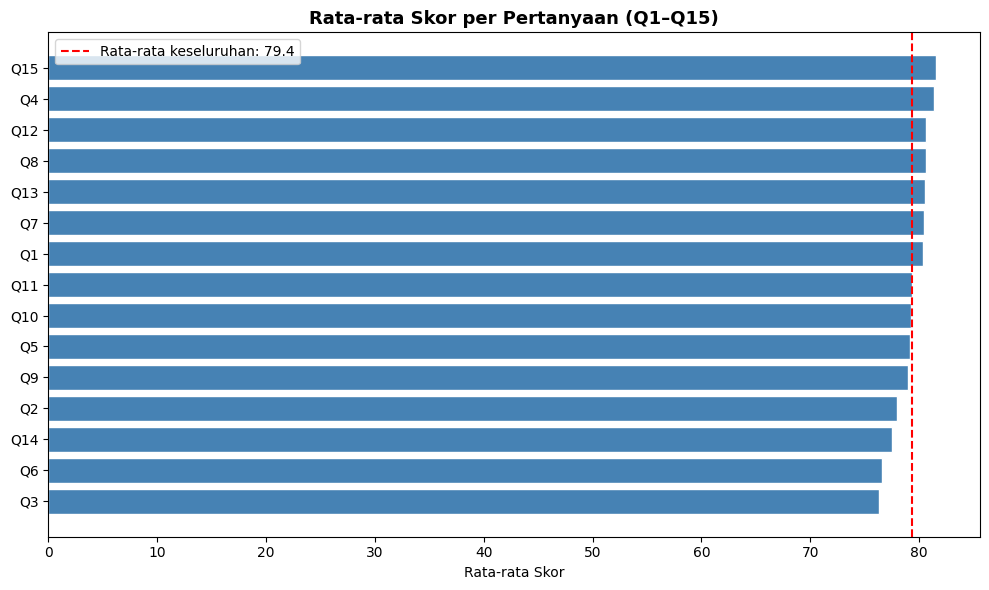

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rata-rata skor tiap pertanyaan
q_means = X.mean().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(q_means.index, q_means.values, color='steelblue', edgecolor='white')
plt.axvline(X.mean().mean(), color='red', linestyle='--', label=f'Rata-rata keseluruhan: {X.mean().mean():.1f}')
plt.title('Rata-rata Skor per Pertanyaan (Q1–Q15)', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Skor')
plt.legend()
plt.tight_layout()
plt.show()